# ***Libraries***

In [ ]:
import pandas as pd
import re
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

from transformers import BertTokenizer, BertForSequenceClassification
import torch
from transformers import Trainer, TrainingArguments

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df = pd.read_csv("/content/Suicide_Detection.csv",
                 usecols=[0, 1, 2],
                 encoding='latin1')

In [ ]:
df.head()

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"Iâm so lostHello, my name is Adam (16) and I...",suicide


In [ ]:
df.columns = ['id', 'text', 'class']
df.head()

,id,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"Iâm so lostHello, my name is Adam (16) and I...",suicide


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233337 entries, 0 to 233336
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      233255 non-null  object
 1   text    232151 non-null  object
 2   class   232087 non-null  object
dtypes: object(3)
memory usage: 5.3+ MB


In [ ]:
df.isnull().sum()

,0
id,82
text,1186
class,1250


In [ ]:
df = df.drop(columns=['id'])

In [ ]:
df.dropna(subset=['text', 'class'], inplace=True)
valid_classes = ['suicide', 'non-suicide']
df = df[df['class'].isin(valid_classes)]

In [ ]:
df.head()

,text,class
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide
3,i need helpjust help me im crying so hard,suicide
4,"Iâm so lostHello, my name is Adam (16) and I...",suicide


In [ ]:
df.isnull().sum()

,0
text,0
class,0


In [ ]:
print("Data Info after cleaning:")
df.info()

Data Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 232045 entries, 0 to 233336
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    232045 non-null  object
 1   class   232045 non-null  object
dtypes: object(2)
memory usage: 5.3+ MB


In [ ]:
df['class'].value_counts()

,count
class,
suicide,116033
non-suicide,116012


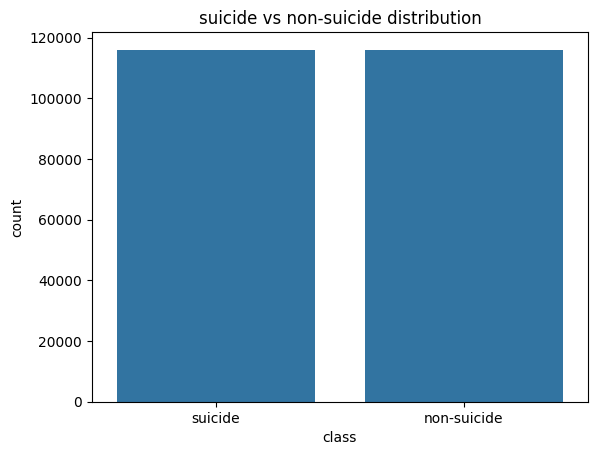

In [ ]:
sns.countplot(x='class',data=df)
plt.title("suicide vs non-suicide distribution")
plt.show()

In [ ]:
df['class'] = df['class'].map({'suicide': 1, 'non-suicide': 0})

In [ ]:
df.head()

,text,class
0,Ex Wife Threatening SuicideRecently I left my ...,1
1,Am I weird I don't get affected by compliments...,0
2,Finally 2020 is almost over... So I can never ...,0
3,i need helpjust help me im crying so hard,1
4,"Iâm so lostHello, my name is Adam (16) and I...",1


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\x00-\x7f]',r' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,Ex Wife Threatening SuicideRecently I left my ...,ex wife threatening suiciderecently i left my ...
1,Am I weird I don't get affected by compliments...,am i weird i dont get affected by compliments ...
2,Finally 2020 is almost over... So I can never ...,finally is almost over so i can never hear has...
3,i need helpjust help me im crying so hard,i need helpjust help me im crying so hard
4,"Iâm so lostHello, my name is Adam (16) and I...",i m so losthello my name is adam and i ve been...


In [ ]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(tokens):
  words = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
  return ' '.join(words)

df['Clean_Text'] = df['tokens'].apply(preprocess_text)

In [ ]:
df = df[df['Clean_Text'].str.strip() != ""]

In [ ]:
output = df[['Clean_Text', 'class']]
output.to_csv('MindWatch_Cleaned.csv', index=False)

print('Saved: MindWatch_Cleaned.csv')
print('Shape:', output.shape)
output.head()

Saved: MindWatch_Cleaned.csv
Shape: (231948, 2)


,Clean_Text,class
0,ex wife threatening suiciderecently left wife ...,1
1,weird dont get affected compliment coming some...,0
2,finally almost never hear bad year ever swear ...,0
3,need helpjust help im cry hard,1
4,losthello name adam struggling year afraid pas...,1



1. **Vectorization** — Bag-of-Words & TF-IDF (unigram and bigram)
2. **Train / Test Split** — Stratified 80/20
3. **Model Training** — Naive Bayes & SVM
4. **N-gram Comparison** — Results table across all configurations

### 1. Train / Test Split

In [ ]:
X = df['Clean_Text'].values
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # keeps suicide/non-suicide ratio equal in both sets
)

print(f'Training samples : {len(X_train):,}')
print(f'Testing  samples : {len(X_test):,}')

Training samples : 185,558
Testing  samples : 46,390


### 2. Vectorization
We build **four** vectorizers to compare

| Config | Type | N-gram range |
|---|---|---|
| `BoW_uni` | CountVectorizer | (1,1) |
| `BoW_bi` | CountVectorizer | (1,2) |
| `TFIDF_uni` | TfidfVectorizer | (1,1) |
| `TFIDF_bi` | TfidfVectorizer | (1,2) |

In [ ]:
COMMON = dict(strip_accents='unicode', min_df=2, max_df=0.95)

vectorizers = {
    'BoW_uni'   : CountVectorizer(ngram_range=(1, 1), **COMMON),
    'BoW_bi'    : CountVectorizer(ngram_range=(1, 2), **COMMON),
    'TFIDF_uni' : TfidfVectorizer(ngram_range=(1, 1), **COMMON),
    'TFIDF_bi'  : TfidfVectorizer(ngram_range=(1, 2), **COMMON),
}

# Fit ONLY on train → transform both (prevents data leakage)
X_train_vec, X_test_vec = {}, {}
for name, vec in vectorizers.items():
    X_train_vec[name] = vec.fit_transform(X_train)
    X_test_vec[name]  = vec.transform(X_test)
    print(f'{name:12s}  vocab: {len(vec.vocabulary_):,}  '
          f'train shape: {X_train_vec[name].shape}')

BoW_uni       vocab: 56,559  train shape: (185558, 56559)
BoW_bi        vocab: 961,167  train shape: (185558, 961167)
TFIDF_uni     vocab: 56,559  train shape: (185558, 56559)
TFIDF_bi      vocab: 961,167  train shape: (185558, 961167)


### 3. Model Training

In [ ]:
def train_evaluate(model, X_tr, X_te, y_tr, y_te, label):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {'label': label,
            'accuracy': round(accuracy_score(y_te, y_pred), 4),
            'y_pred': y_pred,
            'model': model}

nb_results, svm_results = {}, {}

print('=== Naive Bayes ===')
for vname in vectorizers:
    r = train_evaluate(MultinomialNB(alpha=1.0),
                       X_train_vec[vname], X_test_vec[vname],
                       y_train, y_test, f'NB + {vname}')
    nb_results[vname] = r
    print(f"  {r['label']:22s}  accuracy = {r['accuracy']:.4f}")

print()
print('=== SVM (LinearSVC) ===')
for vname in vectorizers:
    r = train_evaluate(LinearSVC(C=1.0, max_iter=2000, random_state=42),
                       X_train_vec[vname], X_test_vec[vname],
                       y_train, y_test, f'SVM + {vname}')
    svm_results[vname] = r
    print(f"  {r['label']:23s}  accuracy = {r['accuracy']:.4f}")

=== Naive Bayes ===
  NB + BoW_uni            accuracy = 0.9115
  NB + BoW_bi             accuracy = 0.9136
  NB + TFIDF_uni          accuracy = 0.9082
  NB + TFIDF_bi           accuracy = 0.8781

=== SVM (LinearSVC) ===
  SVM + BoW_uni            accuracy = 0.9332
  SVM + BoW_bi             accuracy = 0.9327
  SVM + TFIDF_uni          accuracy = 0.9425
  SVM + TFIDF_bi           accuracy = 0.9462


### 4. N-gram Comparison

In [ ]:
import pandas as pd

rows = []
for vname in vectorizers:
    nb_acc  = nb_results[vname]['accuracy']
    svm_acc = svm_results[vname]['accuracy']
    rows.append({'Vectorizer': vname,
                 'Naive Bayes': nb_acc,
                 'SVM': svm_acc,
                 'Best': max(nb_acc, svm_acc)})

comp = pd.DataFrame(rows).set_index('Vectorizer')
print(comp.to_string())
best_vec = comp['Best'].idxmax()
print(f'\n✓ Best config: {best_vec}  (accuracy = {comp.loc[best_vec, "Best"]:.4f})')

            Naive Bayes     SVM    Best
Vectorizer                             
BoW_uni          0.9115  0.9332  0.9332
BoW_bi           0.9136  0.9327  0.9327
TFIDF_uni        0.9082  0.9425  0.9425
TFIDF_bi         0.8781  0.9462  0.9462

✓ Best config: TFIDF_bi  (accuracy = 0.9462)


### 5. Detailed Classification Report (Best Configuration)

In [ ]:
best_vec = comp['Best'].idxmax()
use_svm  = svm_results[best_vec]['accuracy'] >= nb_results[best_vec]['accuracy']
best_res = svm_results[best_vec] if use_svm else nb_results[best_vec]

print(f"Best model: {best_res['label']}\n")
print(classification_report(y_test, best_res['y_pred'],
                            target_names=['non-suicide', 'suicide']))

Best model: SVM + TFIDF_bi

              precision    recall  f1-score   support

 non-suicide       0.94      0.95      0.95     23186
     suicide       0.95      0.94      0.95     23204

    accuracy                           0.95     46390
   macro avg       0.95      0.95      0.95     46390
weighted avg       0.95      0.95      0.95     46390



# **BERT**

In [ ]:
!pip install transformers datasets torch

In [ ]:
df_sample = df.groupby('class').sample(n=5000, random_state=42)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_sample['clean_text'].tolist(),
    df_sample['class'].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
class MindWatchDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MindWatchDataset(train_encodings, train_labels)
val_dataset = MindWatchDataset(val_encodings, val_labels)

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("Starting Fine-tuning... Please wait.")
trainer.train()

print("BERT Training Completed Successfully!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting Fine-tuning... Please wait.


Epoch,Training Loss,Validation Loss
1,0.177218,0.129717
2,0.075208,0.120354
3,0.000922,0.131213


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT Training Completed Successfully!


In [ ]:
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = val_labels

print(f"Overall Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Suicide', 'Suicide']))

Overall Accuracy: 96.65%

Detailed Report:
              precision    recall  f1-score   support

 Non-Suicide       0.96      0.98      0.97      1012
     Suicide       0.98      0.95      0.97       988

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



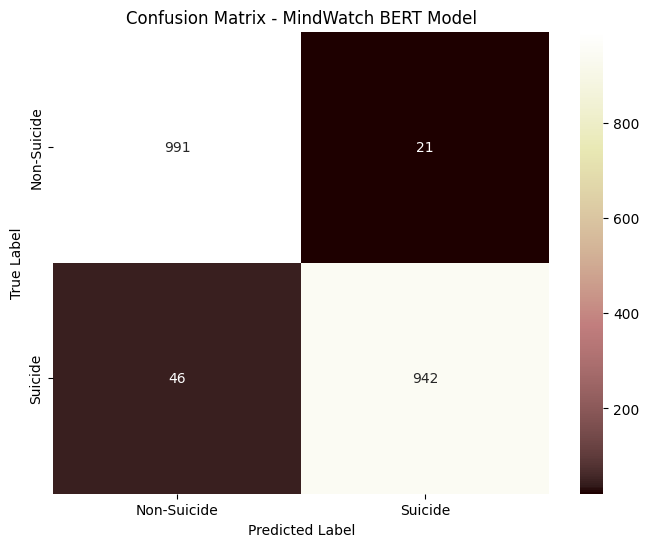

In [ ]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='pink',
            xticklabels=['Non-Suicide', 'Suicide'],
            yticklabels=['Non-Suicide', 'Suicide'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MindWatch BERT Model')
plt.show()

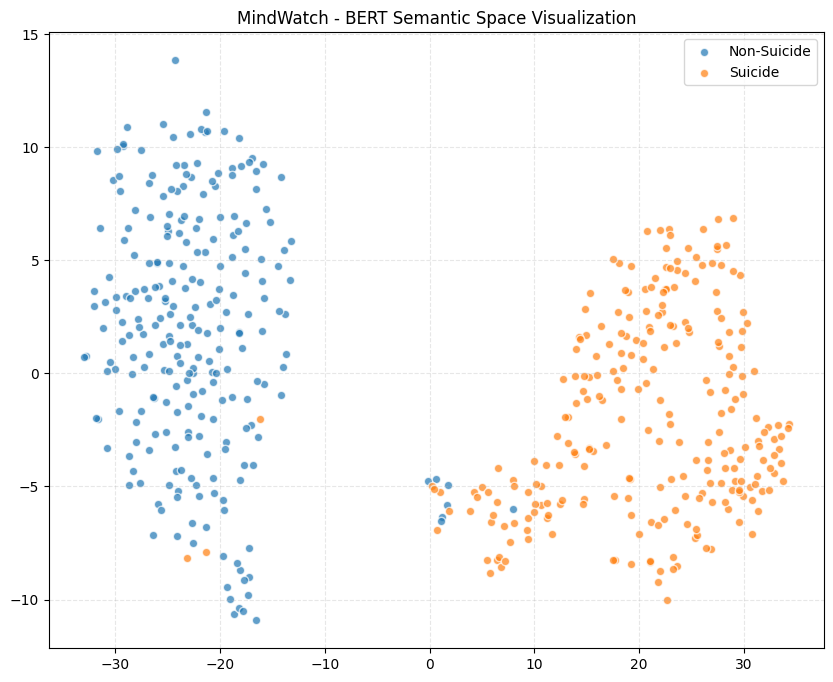

In [ ]:
from sklearn.manifold import TSNE
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

sample_size = 500
sample_encodings = tokenizer(val_texts[:sample_size], truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.bert(**sample_encodings)
    embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
low_dim_embeddings = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
labels = np.array(val_labels[:sample_size])
colors = ['#1f77b4', '#ff7f0e']
for i, label in enumerate(['Non-Suicide', 'Suicide']):
    indices = np.where(labels == i)
    plt.scatter(low_dim_embeddings[indices, 0], low_dim_embeddings[indices, 1], label=label, alpha=0.7, c=colors[i], edgecolors='w')

plt.legend()
plt.title('MindWatch - BERT Semantic Space Visualization')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [ ]:
import joblib

best_vectorizer = vectorizers[best_vec]
best_ml_model = best_res['model']

joblib.dump(best_vectorizer, 'best_vectorizer.pkl')
joblib.dump(best_ml_model, 'best_ml_model.pkl')
print("Saved traditional pipeline components successfully!")


model.save_pretrained('./saved_bert_model')
tokenizer.save_pretrained('./saved_bert_model')
print("Saved BERT model components successfully!")

Saved traditional pipeline components successfully!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BERT model components successfully!


In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
changed 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [ ]:
%%writefile app.py
import streamlit as st
import torch
import joblib
import re
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification

# Page Configuration
st.set_page_config(page_title="MindWatch Platform", page_icon="🧠", layout="centered")

# Cached function to load models once
@st.cache_resource
def load_models():
    vectorizer = joblib.load('best_vectorizer.pkl')
    ml_model = joblib.load('best_ml_model.pkl')
    bert_tokenizer = BertTokenizer.from_pretrained('./saved_bert_model')
    bert_model = BertForSequenceClassification.from_pretrained('./saved_bert_model')
    bert_model.eval()
    return vectorizer, ml_model, bert_tokenizer, bert_model

try:
    vectorizer, ml_model, bert_tokenizer, bert_model = load_models()
except Exception as e:
    st.error("Error: Make sure you have executed the training code and saved the models first!")

# Text Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\x00-\x7f]', r' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# UI Layout
st.title("🧠 MindWatch: Suicide Risk Detection Platform")
st.markdown("Analyze online posts, essays, or text sequences to detect potential indications of self-harm or suicide risks.")
st.markdown("---")

# Input Components
user_input = st.text_area("Input Text Content:", height=150, placeholder="Type or paste your text here...")
model_option = st.selectbox("Select Model Core:", ("Fine-tuned BERT Transformer", "Traditional ML Model (SVM / Naive Bayes)"))

# Inference Trigger
if st.button("Run MindWatch Analysis"):
    if user_input.strip() == "":
        st.warning("Please provide a valid text input before analyzing.")
    else:
        cleaned_text = clean_text(user_input)

        with st.spinner("Analyzing semantics and context..."):
            if model_option == "Traditional ML Model (SVM / Naive Bayes)":
                vec_text = vectorizer.transform([cleaned_text])
                prediction = ml_model.predict(vec_text)[0]
                confidence_info = "Classification based on the model's decision boundary."
            else:
                inputs = bert_tokenizer(cleaned_text, truncation=True, padding=True, max_length=128, return_tensors="pt")
                with torch.no_grad():
                    outputs = bert_model(**inputs)
                    probs = torch.nn.functional.softmax(outputs.logits, dim=-1).flatten().tolist()
                    prediction = np.argmax(probs)
                    confidence_info = f"Transformer Intent Confidence: {probs[prediction]*100:.2f}%"

        # Results Presentation
        st.subheader("Analysis Breakdown:")

        if prediction == 1:
            st.error("Flagged Notification: Suicide Intent Risk Detected.")
            st.metric(label="Status", value="High Risk Indicator")
        else:
            st.success("Analysis Clear: Non-Suicide Text Profile.")
            st.metric(label="Status", value="Low/No Risk Detected")

        st.info(f"ℹ**Metadata Details:** {confidence_info}")

Overwriting app.py


In [ ]:
!curl ipv4.icanhazip.com

34.158.247.24


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦

⠧⠇⠏⠋⠙2026-06-01 13:22:09.782 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.158.247.24:8501

your url is: https://swift-bars-pick.loca.lt
  Stopping...
^C


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3EXMpviuYX6SaNy9hOItoxVE9Oc_2YbDoZMGd8FvW6rs4RVcD"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

import os
os.system("streamlit run app.py --server.port 8501 &")

public_url = ngrok.connect(8501, proto="http")
print("Your App URL is:", public_url)

Your App URL is: NgrokTunnel: "https://charm-swiftly-reliably.ngrok-free.dev" -> "http://localhost:8501"
